In [4]:
!gdown --folder https://drive.google.com/drive/folders/1Tq5Uixwz5J-aG_NfUQdI6X9CIrNz9ZFS -O ../Jobs_2026

Retrieving folder contents
Processing file 1Z0rTOc2SUINtG4n0V4PR1eaPFVPpNwip jobs_2026_part_00001.parquet
Processing file 1m3TpbaVkXGbROBzB_HYHiEsW_qH1qzLT jobs_2026_part_00002.parquet
Processing file 1HDRghQ_9XNEy2hGg_y8x8-Kk_Cpvqk0Q jobs_2026_part_00003.parquet
Processing file 1HUumYFU5D6f8twvb6pOFtDBA1lSbwf1Y jobs_2026_part_00004.parquet
Processing file 1KLKdZpqRtK9PwdvuZLHO7gxstwCwiSgd jobs_2026_part_00005.parquet
Processing file 1LkEXbcD_MsTIFiJWMN5YqGxiqDPkxHxT jobs_2026_part_00006.parquet
Processing file 1nGwzzUgy23WvOZnIw2zYYdSe4h5ci0Q9 jobs_2026_part_00007.parquet
Processing file 1GPYZExMUiusSUuFt5ntOZ7gfoY-7JTmP jobs_2026_part_00008.parquet
Processing file 1tEHOJhDyvP9gZfZG43QM5_fWogB_b_IL jobs_2026_part_00009.parquet
Processing file 1zYtfc9ddNNect5JIS-FTfIjgkqHOgtG1 jobs_2026_part_00010.parquet
Processing file 1WycWAuYVc8sxjmUS_oA_bGlC12bH0Oge jobs_2026_part_00011.parquet
Processing file 15JXVS1n5oDH0aKXuajIVuvtYPd2m6_cB jobs_2026_part_00012.parquet
Processing file 1GO8mwXtJ

In [12]:
from pyspark.sql import SparkSession

In [14]:
import pandas as pd

In [16]:
import plotly.express as px

In [17]:
import plotly.io as pio

In [18]:
import numpy as np

In [19]:
np.random.seed(42)

In [20]:
pio.renderers.default = "notebook+notebook_connected+vscode"

In [23]:
# Initialize Spark Session
spark = SparkSession.builder.appName("CareerCompassData").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/ubuntu/.local/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/06 02:02:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [26]:
# Load Data (all 17 Parquet partition files)
from pathlib import Path
data_dir = (Path.home() / "Jobs_2026").resolve()

In [32]:
df = spark.read.parquet(*[path.as_uri() for path in sorted(data_dir.glob("*.parquet"))])
model_source_cols = [
    "SALARY_TO", "SALARY_FROM", "SALARY",
    "MIN_YEARS_EXPERIENCE", "MAX_YEARS_EXPERIENCE", "DURATION",
    "EDUCATION_LEVELS_NAME", "EMPLOYMENT_TYPE_NAME", "REMOTE_TYPE_NAME",
    "IS_INTERNSHIP", "COMPANY_IS_STAFFING"
]
df = df.select(*model_source_cols)
df = df.dropna(subset=model_source_cols)
from pyspark.sql import functions as F
for col_name, data_type in df.dtypes:
    if data_type == "string":
        df = df.filter(F.trim(F.col(col_name)) != "")

In [33]:
# Show Schema and Sample Data
print("---This is Diagnostic check, No need to print it in the final doc---")

df.printSchema() # comment this line when rendering the submission
df.show(5)

---This is Diagnostic check, No need to print it in the final doc---
root
 |-- SALARY_TO: string (nullable = true)
 |-- SALARY_FROM: string (nullable = true)
 |-- SALARY: string (nullable = true)
 |-- MIN_YEARS_EXPERIENCE: string (nullable = true)
 |-- MAX_YEARS_EXPERIENCE: string (nullable = true)
 |-- DURATION: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- EMPLOYMENT_TYPE_NAME: string (nullable = true)
 |-- REMOTE_TYPE_NAME: string (nullable = true)
 |-- IS_INTERNSHIP: byte (nullable = true)
 |-- COMPANY_IS_STAFFING: byte (nullable = true)

+---------+-----------+--------------------+--------------------+--------------------+--------+---------------------+--------------------+----------------+-------------+-------------------+
|SALARY_TO|SALARY_FROM|              SALARY|MIN_YEARS_EXPERIENCE|MAX_YEARS_EXPERIENCE|DURATION|EDUCATION_LEVELS_NAME|EMPLOYMENT_TYPE_NAME|REMOTE_TYPE_NAME|IS_INTERNSHIP|COMPANY_IS_STAFFING|
+---------+-----------+-----------

In [34]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.sql import functions as F

label_col = "SALARY"
numeric_features = [
    "MIN_YEARS_EXPERIENCE",
    "MAX_YEARS_EXPERIENCE",
    "DURATION",
    "IS_INTERNSHIP",  # Binary numeric feature; salary bounds are excluded to avoid target leakage.
]
categorical_features = ["EMPLOYMENT_TYPE_NAME", "REMOTE_TYPE_NAME"]

model_df = df.select(label_col, *numeric_features, *categorical_features)
for column_name in numeric_features:
    model_df = model_df.withColumn(column_name, F.col(column_name).cast("double"))
model_df = model_df.dropna(subset=[label_col, *numeric_features, *categorical_features])

train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

indexer_stages = [
    StringIndexer(
        inputCol=column_name,
        outputCol=f"{column_name}_index",
        handleInvalid="keep",
    )
    for column_name in categorical_features
]
indexed_category_cols = [f"{column_name}_index" for column_name in categorical_features]
encoded_category_cols = [f"{column_name}_ohe" for column_name in categorical_features]

encoder = OneHotEncoder(
    inputCols=indexed_category_cols,
    outputCols=encoded_category_cols,
    handleInvalid="keep",
)
assembler = VectorAssembler(
    inputCols=numeric_features + encoded_category_cols,
    outputCol="features",
)
preprocessing_pipeline = Pipeline(stages=indexer_stages + [encoder, assembler])

# Fit preprocessing on training data only to avoid category leakage.
preprocessing_model = preprocessing_pipeline.fit(train_df)
train_prepared = preprocessing_model.transform(train_df)
test_prepared = preprocessing_model.transform(test_df)

print(f"Training rows: {train_prepared.count()}")
print(f"Testing rows: {test_prepared.count()}")
train_prepared.select(label_col, "features").show(5, truncate=False)

Training rows: 1482


Testing rows: 323
+-----------------------------------------------------------------------------------------------------------------+-----------------------------------+
|SALARY                                                                                                           |features                           |
+-----------------------------------------------------------------------------------------------------------------+-----------------------------------+
|$30.76 - $32.99 per hour                                                                                         |(36,[1,2,6,31],[1.0,365.0,1.0,1.0])|
|COP 1871400 per MONTH                                                                                            |(36,[1,2,7,31],[1.0,32.0,1.0,1.0]) |
|MonetaryAmount, USD, {'@type': 'QuantitativeValue', 'value': '$20 per hour', 'unitText': 'MONTH'}                |(36,[1,2,4,31],[1.0,30.0,1.0,1.0]) |
|MonetaryAmount, USD, {'@type': 'QuantitativeValue', 'value': '$25.00-

In [37]:
from math import isfinite

import numpy as np
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorSlicer
from pyspark.ml.regression import LinearRegression
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, StringType, StructField, StructType

salary_amount_pattern = r"([0-9][0-9,]*(?:\.[0-9]+)?)"

def add_numeric_salary_label(prepared_df):
    return (
        prepared_df
        .withColumn("label", F.regexp_extract(F.col(label_col), salary_amount_pattern, 1))
        .withColumn("label", F.regexp_replace(F.col("label"), ",", "").cast("double"))
        .dropna(subset=["label"])
    )

train_regression_df = add_numeric_salary_label(train_prepared)
test_regression_df = add_numeric_salary_label(test_prepared)


training_vectors = train_regression_df.select("features").collect()
feature_matrix = np.vstack([row.features.toArray() for row in training_vectors])
design_matrix = np.column_stack([np.ones(feature_matrix.shape[0]), feature_matrix])
independent_positions = [0]
current_rank = 1
for position in range(1, design_matrix.shape[1]):
    candidate_rank = np.linalg.matrix_rank(design_matrix[:, independent_positions + [position]])
    if candidate_rank > current_rank:
        independent_positions.append(position)
        current_rank = candidate_rank
selected_feature_indices = [position - 1 for position in independent_positions if position > 0]

feature_metadata = train_regression_df.schema["features"].metadata.get("ml_attr", {}).get("attrs", {})
all_feature_names = [f"feature_{index}" for index in range(feature_matrix.shape[1])]
for attribute_group in feature_metadata.values():
    for attribute in attribute_group:
        feature_index = attribute.get("idx")
        if feature_index is not None and feature_index < len(all_feature_names):
            all_feature_names[feature_index] = attribute.get("name", all_feature_names[feature_index])
selected_feature_names = [all_feature_names[index] for index in selected_feature_indices]

slicer = VectorSlicer(inputCol="features", outputCol="selected_features", indices=selected_feature_indices)
train_regression_df = slicer.transform(train_regression_df).drop("features").withColumnRenamed("selected_features", "features")
test_regression_df = slicer.transform(test_regression_df).drop("features").withColumnRenamed("selected_features", "features")

linear_regression = LinearRegression(
    featuresCol="features",
    labelCol="label",
    solver="normal",
)
linear_regression_model = linear_regression.fit(train_regression_df)
regression_summary = linear_regression_model.summary
test_predictions = linear_regression_model.transform(test_regression_df)

metric_values = {}
for metric_name in ["r2", "rmse", "mae"]:
    evaluator = RegressionEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_name,
    )
    metric_values[metric_name] = evaluator.evaluate(test_predictions)

print(f"Training rows with numeric SALARY: {train_regression_df.count()}")
print(f"Testing rows with numeric SALARY: {test_regression_df.count()}")
print(f"Independent feature dimensions: {len(selected_feature_indices)} of {feature_matrix.shape[1]}")
print("Coefficients:", linear_regression_model.coefficients)
print("Intercept:", linear_regression_model.intercept)
print(f"Test R²: {metric_values['r2']:.4f}")
print(f"Test RMSE: {metric_values['rmse']:.4f}")
print(f"Test MAE: {metric_values['mae']:.4f}")

standard_errors = list(regression_summary.coefficientStandardErrors)
t_values = list(regression_summary.tValues)
p_values = list(regression_summary.pValues)
coefficient_values = list(linear_regression_model.coefficients)
coefficient_rows = []
confidence_multiplier = 1.959963984540054

for index, coefficient in enumerate(coefficient_values):
    standard_error = float(standard_errors[index]) if index < len(standard_errors) else None
    t_value = float(t_values[index]) if index < len(t_values) else None
    p_value = float(p_values[index]) if index < len(p_values) else None
    if standard_error is not None and isfinite(standard_error):
        lower_bound = float(coefficient) - confidence_multiplier * standard_error
        upper_bound = float(coefficient) + confidence_multiplier * standard_error
    else:
        lower_bound = None
        upper_bound = None
    coefficient_rows.append((
        selected_feature_names[index], float(coefficient), standard_error, t_value,
        p_value, lower_bound, upper_bound,
    ))

if len(standard_errors) > len(coefficient_values):
    intercept_standard_error = float(standard_errors[-1])
    intercept_t_value = float(t_values[-1]) if len(t_values) > len(coefficient_values) else None
    intercept_p_value = float(p_values[-1]) if len(p_values) > len(coefficient_values) else None
    if isfinite(intercept_standard_error):
        intercept_lower = float(linear_regression_model.intercept) - confidence_multiplier * intercept_standard_error
        intercept_upper = float(linear_regression_model.intercept) + confidence_multiplier * intercept_standard_error
    else:
        intercept_lower = None
        intercept_upper = None
    coefficient_rows.append((
        "(intercept)", float(linear_regression_model.intercept),
        intercept_standard_error, intercept_t_value, intercept_p_value,
        intercept_lower, intercept_upper,
    ))

coefficient_schema = StructType([
    StructField("term", StringType(), False),
    StructField("coefficient", DoubleType(), False),
    StructField("standard_error", DoubleType(), True),
    StructField("t_value", DoubleType(), True),
    StructField("p_value", DoubleType(), True),
    StructField("ci_95_lower_approx", DoubleType(), True),
    StructField("ci_95_upper_approx", DoubleType(), True),
])
coefficient_table = spark.createDataFrame(coefficient_rows, schema=coefficient_schema)
print("\nCoefficient statistics (95% confidence intervals are normal approximations):")
coefficient_table.show(100, truncate=False)

print("\nCoefficient interpretation, holding the other inputs constant:")
for index, row in enumerate(coefficient_rows[:len(coefficient_values)]):
    term, coefficient, _, _, p_value, _, _ = row
    significance = "significant at p < 0.05" if p_value is not None and p_value < 0.05 else "not significant at p < 0.05"
    if selected_feature_indices[index] < len(numeric_features):
        comparison = "per one-unit increase"
    else:
        comparison = "relative to the omitted one-hot reference category"
    print(f"{term}: {coefficient:+.4g} salary units {comparison}; {significance} (p={p_value:.4g}).")


26/10/06 02:24:08 WARN Instrumentation: [5ed71365] regParam is zero, which might cause numerical instability and overfitting.


Training rows with numeric SALARY: 1482


Testing rows with numeric SALARY: 323
Independent feature dimensions: 31 of 36
Coefficients: [9317.44567328111,-807.4177993676874,-46.62511599470917,-11486.821995754173,6500.04423422228,1079.2530443717253,-5850.103927543778,32322.173731256495,14243.795481872696,-11857.558841310645,-4352.319740944851,25351.03510039774,-6829.362142701172,-4061.4258351188446,-2021.8055243399826,-145.67655494870513,-8191.771542399066,17474.38721144041,-16387.8904898097,23.460000023724472,-4794.528034040496,-11019.906898521316,-18956.246190073667,-8377.308321026589,-11231.906898521309,-13599.221312434056,-17.999999976281977,1596.835598759122,-35619.162266420775,-33488.58295041343,7518.904654579506]
Intercept: 53462.747403833615
Test R²: 0.1589
Test RMSE: 34461.9117
Test MAE: 21455.9728

Coefficient statistics (95% confidence intervals are normal approximations):
+------------------------------------------------------------------+-------------------+------------------+----------------------+-----------------

In [ ]:
from math import isfinite

import numpy as np
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import PolynomialExpansion, VectorSlicer
from pyspark.ml.linalg import Vectors
from pyspark.ml.regression import LinearRegression
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, StringType, StructField, StructType

# Expand the assembled vectors to degree 2. With 36 base dimensions, this creates 702 terms.
polynomial_expansion = PolynomialExpansion(
    degree=2,
    inputCol="features",
    outputCol="features_poly",
)
train_poly_df = add_numeric_salary_label(polynomial_expansion.transform(train_prepared))
test_poly_df = add_numeric_salary_label(polynomial_expansion.transform(test_prepared))

training_poly_vectors = train_poly_df.select("features_poly").collect()
poly_matrix = np.vstack([row.features_poly.toArray() for row in training_poly_vectors])
column_norms = np.linalg.norm(poly_matrix, axis=0)
nonzero_indices = np.flatnonzero(column_norms > 0)
normalized_matrix = poly_matrix[:, nonzero_indices] / column_norms[nonzero_indices]
intercept_vector = np.ones(normalized_matrix.shape[0]) / np.sqrt(normalized_matrix.shape[0])
residual_matrix = normalized_matrix - np.outer(intercept_vector, intercept_vector @ normalized_matrix)
orthonormal_basis = intercept_vector.reshape(-1, 1)
selected_poly_indices = []
rank_tolerance = 1e-8

while residual_matrix.shape[1] > 0:
    residual_norms = np.linalg.norm(residual_matrix, axis=0)
    pivot = int(np.argmax(residual_norms))
    if residual_norms[pivot] <= rank_tolerance:
        break
    candidate = residual_matrix[:, pivot].copy()
    for _ in range(2):
        candidate -= orthonormal_basis @ (orthonormal_basis.T @ candidate)
    candidate_norm = np.linalg.norm(candidate)
    if candidate_norm <= rank_tolerance:
        residual_matrix[:, pivot] = 0.0
        continue
    basis_vector = candidate / candidate_norm
    selected_poly_indices.append(int(nonzero_indices[pivot]))
    orthonormal_basis = np.column_stack((orthonormal_basis, basis_vector))
    residual_matrix -= np.outer(basis_vector, basis_vector @ residual_matrix)
    residual_matrix -= np.outer(basis_vector, basis_vector @ residual_matrix)
    residual_matrix[:, pivot] = 0.0

selected_poly_indices = sorted(selected_poly_indices)
if not selected_poly_indices:
    raise ValueError("Polynomial expansion produced no independent feature columns.")

# Map Spark's expansion order to exact monomial names using unique prime products.
base_metadata = train_prepared.schema["features"].metadata.get("ml_attr", {}).get("attrs", {})
base_feature_size = train_prepared.select("features").first().features.size
base_feature_names = [f"feature_{index}" for index in range(base_feature_size)]
for attribute_group in base_metadata.values():
    for attribute in attribute_group:
        feature_index = attribute.get("idx")
        if feature_index is not None and feature_index < len(base_feature_names):
            base_feature_names[feature_index] = attribute.get("name", base_feature_names[feature_index])
probe_primes = []
candidate = 2
while len(probe_primes) < base_feature_size:
    if all(candidate % divisor for divisor in range(2, int(np.sqrt(candidate)) + 1)):
        probe_primes.append(candidate)
    candidate += 1
monomial_name_by_value = {
    prime: base_feature_names[index]
    for index, prime in enumerate(probe_primes)
}
for left_index, left_prime in enumerate(probe_primes):
    for right_index in range(left_index, len(probe_primes)):
        monomial_name_by_value[left_prime * probe_primes[right_index]] = (
            f"{base_feature_names[left_index]} x {base_feature_names[right_index]}"
        )
probe_df = spark.createDataFrame([(Vectors.dense(probe_primes),)], ["features"])
probe_expanded = polynomial_expansion.transform(probe_df).first().features_poly.toArray()
poly_feature_names = [monomial_name_by_value[int(round(value))] for value in probe_expanded]
if len(poly_feature_names) != poly_matrix.shape[1]:
    raise ValueError("Could not map all polynomial feature positions to names.")

poly_slicer = VectorSlicer(
    inputCol="features_poly",
    outputCol="features_poly_independent",
    indices=selected_poly_indices,
)
train_poly_model_df = poly_slicer.transform(train_poly_df).drop("features_poly").withColumnRenamed(
    "features_poly_independent", "features_poly"
)
test_poly_model_df = poly_slicer.transform(test_poly_df).drop("features_poly").withColumnRenamed(
    "features_poly_independent", "features_poly"
)

polynomial_regression = LinearRegression(
    featuresCol="features_poly",
    labelCol="label",
    solver="normal",
)
polynomial_regression_model = polynomial_regression.fit(train_poly_model_df)
polynomial_summary = polynomial_regression_model.summary
poly_test_predictions = polynomial_regression_model.transform(test_poly_model_df)

polynomial_metrics = {}
for metric_name in ("r2", "rmse", "mae"):
    evaluator = RegressionEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_name,
    )
    polynomial_metrics[metric_name] = evaluator.evaluate(poly_test_predictions)

print(f"Training rows with numeric SALARY: {train_poly_model_df.count()}")
print(f"Testing rows with numeric SALARY: {test_poly_model_df.count()}")
print(f"Polynomial dimensions retained: {len(selected_poly_indices)} of {poly_matrix.shape[1]}")
print("Polynomial coefficients:", polynomial_regression_model.coefficients)
print("Polynomial intercept:", polynomial_regression_model.intercept)
print(f"Test R²: {polynomial_metrics['r2']:.4f}")
print(f"Test RMSE: {polynomial_metrics['rmse']:.4f}")
print(f"Test MAE: {polynomial_metrics['mae']:.4f}")

poly_standard_errors = list(polynomial_summary.coefficientStandardErrors)
poly_t_values = list(polynomial_summary.tValues)
poly_p_values = list(polynomial_summary.pValues)
poly_coefficients = list(polynomial_regression_model.coefficients)
poly_rows = []
confidence_multiplier = 1.959963984540054
for index, coefficient in enumerate(poly_coefficients):
    standard_error = float(poly_standard_errors[index])
    t_value = float(poly_t_values[index])
    p_value = float(poly_p_values[index])
    lower_bound = float(coefficient) - confidence_multiplier * standard_error
    upper_bound = float(coefficient) + confidence_multiplier * standard_error
    feature_index = selected_poly_indices[index]
    feature_name = poly_feature_names[feature_index]
    poly_rows.append((feature_name, float(coefficient), standard_error, t_value, p_value, lower_bound, upper_bound))

if len(poly_standard_errors) > len(poly_coefficients):
    intercept_se = float(poly_standard_errors[-1])
    intercept_t = float(poly_t_values[-1])
    intercept_p = float(poly_p_values[-1])
    intercept = float(polynomial_regression_model.intercept)
    poly_rows.append((
        "(intercept)", intercept, intercept_se, intercept_t, intercept_p,
        intercept - confidence_multiplier * intercept_se,
        intercept + confidence_multiplier * intercept_se,
    ))

polynomial_coefficient_schema = StructType([
    StructField("term", StringType(), False),
    StructField("coefficient", DoubleType(), False),
    StructField("standard_error", DoubleType(), True),
    StructField("t_value", DoubleType(), True),
    StructField("p_value", DoubleType(), True),
    StructField("ci_95_lower_approx", DoubleType(), True),
    StructField("ci_95_upper_approx", DoubleType(), True),
])
polynomial_coefficient_table = spark.createDataFrame(poly_rows, polynomial_coefficient_schema)
print("\nPolynomial coefficient statistics (approximate 95% confidence intervals):")
polynomial_coefficient_table.orderBy("p_value").show(30, truncate=False)

significant_poly_rows = [row for row in poly_rows if row[0] != "(intercept)" and row[4] < 0.05]
print(f"\nSignificant polynomial terms at p < 0.05: {len(significant_poly_rows)}")
for term, coefficient, _, _, p_value, lower_bound, upper_bound in sorted(significant_poly_rows, key=lambda row: row[4]):
    print(f"{term}: coefficient={coefficient:+.4g}, p={p_value:.4g}, approximate 95% CI=({lower_bound:.4g}, {upper_bound:.4g}).")
if not significant_poly_rows:
    print("No polynomial terms are significant at p < 0.05.")

print("R² is the fraction of test-set variation explained (it can be negative); RMSE penalizes larger errors, while MAE is average absolute error.")
print("The target is the first numeric amount parsed from SALARY text; mixed currencies and pay periods limit interpretation of coefficients and metrics.")

26/10/06 02:35:14 WARN Instrumentation: [7137ec07] regParam is zero, which might cause numerical instability and overfitting.


Training rows with numeric SALARY: 1482


Testing rows with numeric SALARY: 323
Polynomial dimensions retained: 99 of 702
Polynomial coefficients: [-473.4202390455713,-65.11808113179323,739.0175724135812,-3.988370811863306,-16.501355116472396,0.029366314204879288,-21142.23997403584,5227.348110755182,-50.48396856341513,3483.8891863519966,-36.2656061710591,13510.32215077844,-9189.189452612962,-2.600203673438704,-9039.990351224831,508.054274399096,-62.87545653432195,-33857.17395635561,-21.43109603295848,70498.52601720685,-8.467138018032522,-105384.99464149894,83120.789721717,-14.669216964457531,8513.8568008698,97.47025531339372,-8.566344224475118,7761.003637985142,1.3859964468940555,-1351.3394763128142,-67.51077466682361,-28.18501123822881,6.260662545749567,4660.390076603904,-210.94233610435623,4.719481348182629,-17047.104763481235,-16131.977355625606,-3462.9376584215993,-19114.78902371988,5.551299343119626,-16343.977355625611,-19101.363304741215,12.39140348007935,-17088.56476348122,-10954.716107764998,-17070.564763481227,1503.53

In [40]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import RandomForestRegressor

rf_train_df = add_numeric_salary_label(train_prepared)
rf_test_df = add_numeric_salary_label(test_prepared)

random_forest = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=200,
    maxDepth=6,
    seed=42,
)
random_forest_model = random_forest.fit(rf_train_df)
rf_test_predictions = random_forest_model.transform(rf_test_df)

rf_metrics = {}
for metric_name in ("r2", "rmse", "mae"):
    evaluator = RegressionEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_name,
    )
    rf_metrics[metric_name] = evaluator.evaluate(rf_test_predictions)

print("Random Forest parameters: numTrees=200, maxDepth=6")
print(f"Training rows with numeric SALARY: {rf_train_df.count()}")
print(f"Testing rows with numeric SALARY: {rf_test_df.count()}")
print(f"Test R²: {rf_metrics['r2']:.4f}")
print(f"Test RMSE: {rf_metrics['rmse']:.4f}")
print(f"Test MAE: {rf_metrics['mae']:.4f}")
print("Feature importances:")
print(random_forest_model.featureImportances)

26/10/06 02:38:46 WARN DAGScheduler: Broadcasting large task binary with size 1416.6 KiB


Random Forest parameters: numTrees=200, maxDepth=6


Training rows with numeric SALARY: 1482


Testing rows with numeric SALARY: 323
Test R²: 0.1783
Test RMSE: 34061.4395
Test MAE: 20378.9086
Feature importances:
(36,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,27,31,32,33,34],[0.08052407858642496,0.08824868337778638,0.33836753067200664,1.2770853005327519e-05,0.02825240967511145,0.008048809948167944,0.022917287692199258,0.1336794312902056,0.01098599796818817,0.011099395543812458,0.00103765276384165,0.010425019441468704,0.0002783315558082665,0.001016973351631019,3.602511220130579e-05,0.0007454220343164479,5.579428972547051e-05,0.0014579779195781324,0.0009464505611923006,2.6218170524594426e-06,2.5433056011333855e-05,6.661917589629977e-05,8.842962701763625e-06,9.679169399531957e-06,5.746512274702923e-06,1.4031699038470407e-05,0.052667639815068265,0.03386898186236744,0.11428124720993736,0.06091311408358078])


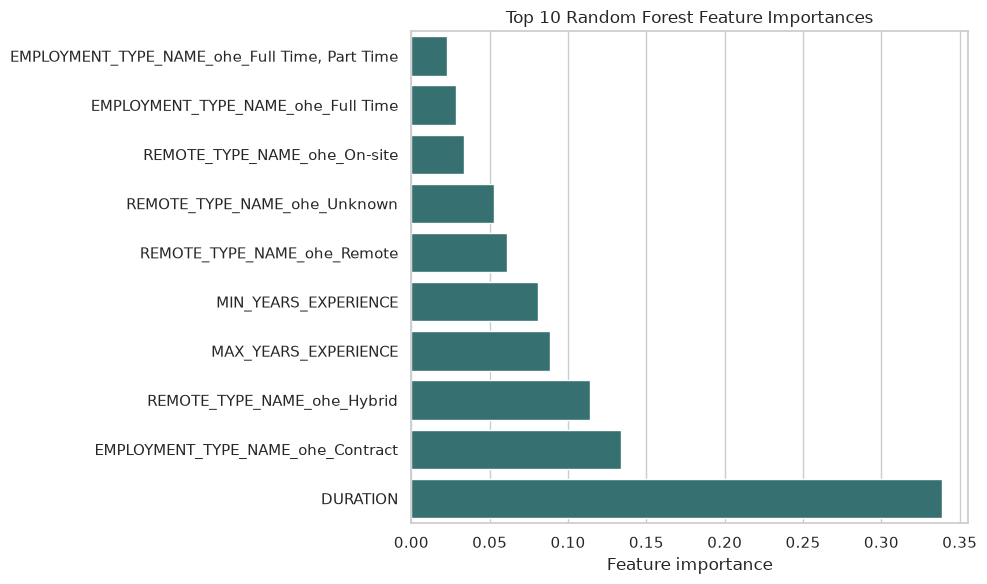

Saved feature importance plot to: /home/ubuntu/.config/_output/rf_feature_importance.png


In [41]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rf_importances = random_forest_model.featureImportances.toArray()
rf_feature_metadata = rf_train_df.schema["features"].metadata.get("ml_attr", {}).get("attrs", {})
rf_feature_names = [f"feature_{index}" for index in range(len(rf_importances))]
for attribute_group in rf_feature_metadata.values():
    for attribute in attribute_group:
        feature_index = attribute.get("idx")
        if feature_index is not None and feature_index < len(rf_feature_names):
            rf_feature_names[feature_index] = attribute.get("name", rf_feature_names[feature_index])

rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances,
})
rf_top10 = (
    rf_importance_df
    .nlargest(10, "importance")
    .sort_values("importance", ascending=True)
)

output_dir = Path.cwd() / "_output"
output_dir.mkdir(parents=True, exist_ok=True)
plot_path = output_dir / "rf_feature_importance.png"

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=rf_top10, x="importance", y="feature", color="#2C7A7B", ax=ax)
ax.set_title("Top 10 Random Forest Feature Importances")
ax.set_xlabel("Feature importance")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved feature importance plot to: {plot_path}")

/home/ubuntu/.local/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/ubuntu/.local/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Actual and test predictions (one row per shared test observation):
 actual  glr_prediction  polynomial_prediction  random_forest_prediction
    0.0    20925.205077           20767.494917              14654.128061
    0.0    23256.460876           24025.725527              20225.645414
    0.0     6982.812001          -61862.054436              18440.000596
    0.0    16670.041787           15170.962143              14078.740030
    0.0    32340.173731           39054.516338              25967.689383

Model comparison:
        model    test_RMSE    train_AIC    train_BIC                                          AIC_method  parameter_count_used
          GLR 34461.911668 36971.330708 37146.268586                        Gaussian residual likelihood                    33
   Polynomial 36349.900518 37054.271068 37589.686996                        Gaussian residual likelihood                   101
Random Forest 34061.439473 47941.211725 77850.287645 Gaussian approximation; leaf-count complex

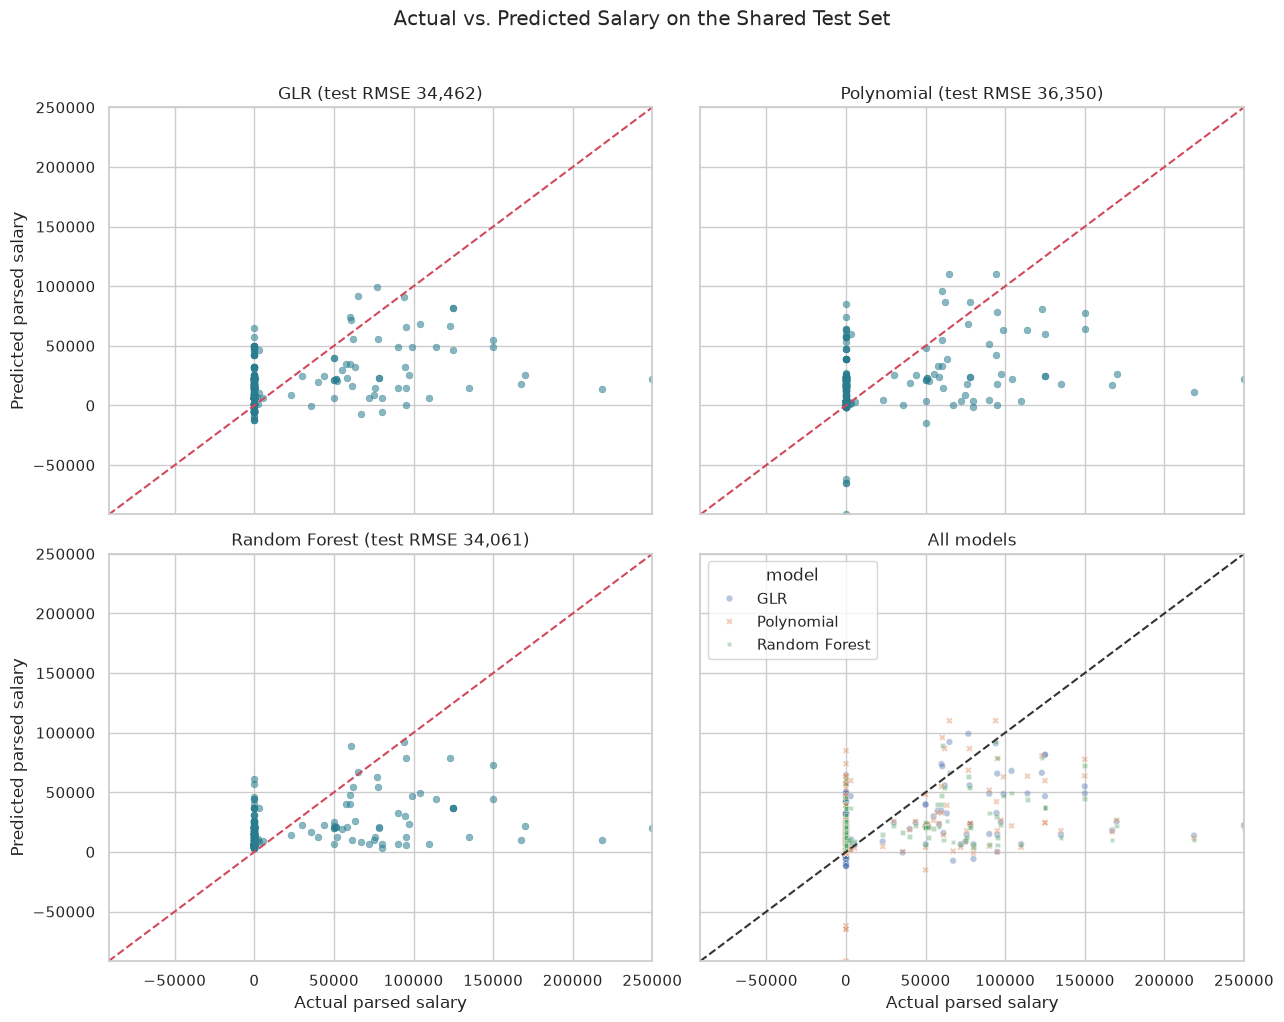

DataFrame[SALARY: string, MIN_YEARS_EXPERIENCE: double, MAX_YEARS_EXPERIENCE: double, DURATION: double, IS_INTERNSHIP: double, EMPLOYMENT_TYPE_NAME: string, REMOTE_TYPE_NAME: string, EMPLOYMENT_TYPE_NAME_index: double, REMOTE_TYPE_NAME_index: double, EMPLOYMENT_TYPE_NAME_ohe: vector, REMOTE_TYPE_NAME_ohe: vector, features: vector, label: double, _comparison_row_id: bigint]

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Add a stable key once, then score each model from the same cached test rows.
comparison_test_base = (
    add_numeric_salary_label(test_prepared)
    .withColumn("_comparison_row_id", F.monotonically_increasing_id())
    .cache()
)
comparison_test_base.count()

# Rebuild each model's expected feature column from the shared assembled test frame.
glr_test_input = slicer.transform(comparison_test_base).drop("features").withColumnRenamed(
    "selected_features", "features"
)
poly_test_input = polynomial_expansion.transform(comparison_test_base)
poly_test_input = poly_slicer.transform(poly_test_input).drop("features_poly").withColumnRenamed(
    "features_poly_independent", "features_poly"
)

comparison_test_inputs = {
    "GLR": (linear_regression_model, glr_test_input),
    "Polynomial": (polynomial_regression_model, poly_test_input),
    "Random Forest": (random_forest_model, comparison_test_base),
}
comparison_sdf = comparison_test_base.select(
    "_comparison_row_id", F.col("label").alias("actual")
)
for model_name, (model, model_input) in comparison_test_inputs.items():
    prediction_column = f"{model_name.lower().replace(' ', '_')}_prediction"
    model_predictions = model.transform(model_input).select(
        "_comparison_row_id", F.col("prediction").alias(prediction_column)
    )
    comparison_sdf = comparison_sdf.join(model_predictions, "_comparison_row_id", "inner")

prediction_comparison_df = (
    comparison_sdf
    .drop("_comparison_row_id")
    .orderBy("actual")
    .toPandas()
)

# AIC/BIC use training residuals. Prefer a model-summary AIC when available;
# otherwise use the Gaussian residual-likelihood formula. RF uses total leaf count as a rough complexity proxy.
training_model_inputs = {
    "GLR": (linear_regression_model, train_regression_df, linear_regression_model.summary),
    "Polynomial": (polynomial_regression_model, train_poly_model_df, polynomial_summary),
    "Random Forest": (random_forest_model, rf_train_df, None),
}
metric_rows = []
for model_name, (model, training_input, model_summary) in training_model_inputs.items():
    prediction_column = f"{model_name.lower().replace(' ', '_')}_prediction"
    residual_stats = (
        model.transform(training_input)
        .select((F.col("label") - F.col("prediction")).alias("residual"))
        .agg(
            F.count("*").alias("n"),
            F.sum(F.pow("residual", 2)).alias("rss"),
        )
        .first()
    )
    train_n = int(residual_stats["n"])
    train_rss = float(residual_stats["rss"])
    if model_name == "Random Forest":
        effective_parameters = sum((tree.numNodes + 1) // 2 for tree in model.trees) + 1
        aic_method = "Gaussian approximation; leaf-count complexity proxy"
    else:
        effective_parameters = len(model.coefficients) + 2
        aic_method = "Gaussian residual likelihood"
        try:
            summary_aic = float(model_summary.aic)
            aic_method = "model summary"
        except Exception:
            summary_aic = None
    residual_variance = max(train_rss / train_n, np.finfo(float).tiny)
    gaussian_likelihood_term = train_n * (np.log(2.0 * np.pi) + 1.0 + np.log(residual_variance))
    if model_name != "Random Forest" and summary_aic is not None:
        aic_value = summary_aic
    else:
        aic_value = gaussian_likelihood_term + 2.0 * effective_parameters
    bic_value = gaussian_likelihood_term + effective_parameters * np.log(train_n)

    actual_values = prediction_comparison_df["actual"].to_numpy(dtype=float)
    predicted_values = prediction_comparison_df[prediction_column].to_numpy(dtype=float)
    rmse_value = float(np.sqrt(np.mean((actual_values - predicted_values) ** 2)))
    metric_rows.append({
        "model": model_name,
        "test_RMSE": rmse_value,
        "train_AIC": aic_value,
        "train_BIC": bic_value,
        "AIC_method": aic_method,
        "parameter_count_used": effective_parameters,
    })

model_comparison_df = pd.DataFrame(metric_rows)
print("Actual and test predictions (one row per shared test observation):")
print(prediction_comparison_df.head().to_string(index=False))
print("\nModel comparison:")
print(model_comparison_df.to_string(index=False))
print("\nAIC/BIC caveat: values use training residuals and a Gaussian-error approximation when a native summary AIC is unavailable. Random Forest has no standard likelihood-based AIC/BIC; its values use total terminal leaves as an approximate complexity count and should not be treated as formally comparable criteria.")

# Three model-specific actual-vs-predicted panels plus a shared overlay panel.
model_names = ["GLR", "Polynomial", "Random Forest"]
prediction_columns = {
    "GLR": "glr_prediction",
    "Polynomial": "polynomial_prediction",
    "Random Forest": "random_forest_prediction",
}
plot_long_df = pd.concat([
    prediction_comparison_df[["actual", prediction_columns[model_name]]]
    .rename(columns={prediction_columns[model_name]: "predicted"})
    .assign(model=model_name)
    for model_name in model_names
], ignore_index=True)
axis_min = float(min(prediction_comparison_df["actual"].min(), plot_long_df["predicted"].min()))
axis_max = float(max(prediction_comparison_df["actual"].max(), plot_long_df["predicted"].max()))

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
for ax, model_name in zip(axes.flat[:3], model_names):
    prediction_column = prediction_columns[model_name]
    sns.scatterplot(
        data=prediction_comparison_df,
        x="actual",
        y=prediction_column,
        ax=ax,
        s=24,
        alpha=0.55,
        color="#287C8E",
        edgecolor=None,
    )
    ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", color="#D1495B")
    rmse_value = model_comparison_df.loc[model_comparison_df["model"] == model_name, "test_RMSE"].iloc[0]
    ax.set_title(f"{model_name} (test RMSE {rmse_value:,.0f})")
    ax.set_xlabel("Actual parsed salary")
    ax.set_ylabel("Predicted parsed salary")
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

sns.scatterplot(
    data=plot_long_df,
    x="actual",
    y="predicted",
    hue="model",
    style="model",
    alpha=0.4,
    s=22,
    ax=axes.flat[3],
)
axes.flat[3].plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", color="#333333")
axes.flat[3].set_title("All models")
axes.flat[3].set_xlabel("Actual parsed salary")
axes.flat[3].set_ylabel("Predicted parsed salary")
axes.flat[3].set_xlim(axis_min, axis_max)
axes.flat[3].set_ylim(axis_min, axis_max)
fig.suptitle("Actual vs. Predicted Salary on the Shared Test Set", y=1.02)
fig.tight_layout()
plt.show()
comparison_test_base.unpersist()

In [44]:
# Recompute information criteria with explicit deviance, dispersion, and log-likelihood values.
def read_model_summary_value(model_summary, property_name):
    if model_summary is None:
        return None
    try:
        value = float(getattr(model_summary, property_name))
    except Exception:
        return None
    return value if np.isfinite(value) else None

information_criteria_rows = []
for model_name, (model, training_input, model_summary) in training_model_inputs.items():
    residual_stats = (
        model.transform(training_input)
        .select((F.col("label") - F.col("prediction")).alias("residual"))
        .agg(
            F.count("*").alias("n"),
            F.sum(F.pow("residual", 2)).alias("rss"),
        )
        .first()
    )
    n_observations = int(residual_stats["n"])
    rss = float(residual_stats["rss"])

    summary_deviance = read_model_summary_value(model_summary, "deviance")
    summary_dispersion = read_model_summary_value(model_summary, "dispersion")
    if summary_deviance is not None and summary_dispersion is not None and summary_dispersion > 0:
        deviance = summary_deviance
        dispersion = summary_dispersion
        likelihood_source = "model summary"
    else:
        deviance = rss
        dispersion = max(rss / n_observations, np.finfo(float).tiny)
        likelihood_source = "Gaussian residual fallback (dispersion = RSS / n)"

    log_likelihood = -0.5 * (
        n_observations * np.log(2.0 * np.pi)
        + n_observations * np.log(dispersion)
        + deviance / dispersion
    )
    summary_aic = read_model_summary_value(model_summary, "aic")
    if summary_aic is not None:
        aic = summary_aic
        aic_source = "model summary"
    else:
        if model_name == "Random Forest":
            parameter_count = sum((tree.numNodes + 1) // 2 for tree in model.trees) + 1
            aic_source = "Gaussian approximation; total leaf-count proxy"
        else:
            parameter_count = len(model.coefficients) + 2
            aic_source = likelihood_source
        aic = 2 * parameter_count - 2 * log_likelihood

    if model_name == "Random Forest":
        parameter_count = sum((tree.numNodes + 1) // 2 for tree in model.trees) + 1
    else:
        parameter_count = len(model.coefficients) + 2
    bic = parameter_count * np.log(n_observations) - 2 * log_likelihood

    prediction_column = f"{model_name.lower().replace(' ', '_')}_prediction"
    actual = prediction_comparison_df["actual"].to_numpy(dtype=float)
    predicted = prediction_comparison_df[prediction_column].to_numpy(dtype=float)
    test_rmse = float(np.sqrt(np.mean((actual - predicted) ** 2)))
    information_criteria_rows.append({
        "model": model_name,
        "test_RMSE": test_rmse,
        "training_n": n_observations,
        "deviance": deviance,
        "dispersion": dispersion,
        "log_likelihood": log_likelihood,
        "train_AIC": aic,
        "train_BIC": bic,
        "parameter_count_used": parameter_count,
        "likelihood_source": likelihood_source,
        "AIC_source": aic_source,
    })

model_comparison_df = pd.DataFrame(information_criteria_rows)
print("Log Likelihood = -0.5 * (n*log(2*pi) + n*log(dispersion) + deviance/dispersion)")
print("BIC = k*log(n) - 2*Log Likelihood; AIC = 2*k - 2*Log Likelihood")
print(model_comparison_df.to_string(index=False))
print("Gaussian fallback, deviance=RSS and dispersion=RSS/n.")

Log Likelihood = -0.5 * (n*log(2*pi) + n*log(dispersion) + deviance/dispersion)
BIC = k*log(n) - 2*Log Likelihood; AIC = 2*k - 2*Log Likelihood
        model    test_RMSE  training_n     deviance   dispersion  log_likelihood    train_AIC    train_BIC  parameter_count_used                                 likelihood_source                                        AIC_source
          GLR 34461.911668        1482 5.666842e+12 3.823780e+09   -18452.665354 36971.330708 37146.268586                    33 Gaussian residual fallback (dispersion = RSS / n) Gaussian residual fallback (dispersion = RSS / n)
   Polynomial 36349.900518        1482 5.467543e+12 3.689300e+09   -18426.135534 37054.271068 37589.686996                   101 Gaussian residual fallback (dispersion = RSS / n) Gaussian residual fallback (dispersion = RSS / n)
Random Forest 34061.439473        1482 4.793258e+12 3.234317e+09   -18328.605862 47941.211725 77850.287645                  5642 Gaussian residual fallback (dispersion =